In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('Unemployment_in_India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

df1.columns, df2.columns

(Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
        'Estimated Employed', 'Estimated Labour Participation Rate (%)',
        'Area'],
       dtype='object'),
 Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
        'Estimated Employed', 'Estimated Labour Participation Rate (%)',
        'Region.1', 'longitude', 'latitude'],
       dtype='object'))

In [4]:
for df in (df1, df2):
    for col in df.columns:
        if 'date' in col.lower():
            df.rename(columns={col: 'Date'}, inplace=True)


df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True, errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True, errors='coerce')

df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
for df in (df1, df2):
    for col in df.columns:
        if 'unemp' in col.lower():
            df.rename(columns={col: 'Unemployment_Rate'}, inplace=True)

df1[['Region', 'Date', 'Unemployment_Rate']].head()

,Region,Date,Unemployment_Rate
0,Andhra Pradesh,2019-05-31,3.65
1,Andhra Pradesh,2019-06-30,3.05
2,Andhra Pradesh,2019-07-31,3.75
3,Andhra Pradesh,2019-08-31,3.32
4,Andhra Pradesh,2019-09-30,5.17


In [6]:
df1_clean = df1[['Region', 'Date', 'Unemployment_Rate']]
df2_clean = df2[['Region', 'Date', 'Unemployment_Rate']]

combined = pd.concat([df1_clean, df2_clean])

combined.head()

,Region,Date,Unemployment_Rate
0,Andhra Pradesh,2019-05-31,3.65
1,Andhra Pradesh,2019-06-30,3.05
2,Andhra Pradesh,2019-07-31,3.75
3,Andhra Pradesh,2019-08-31,3.32
4,Andhra Pradesh,2019-09-30,5.17


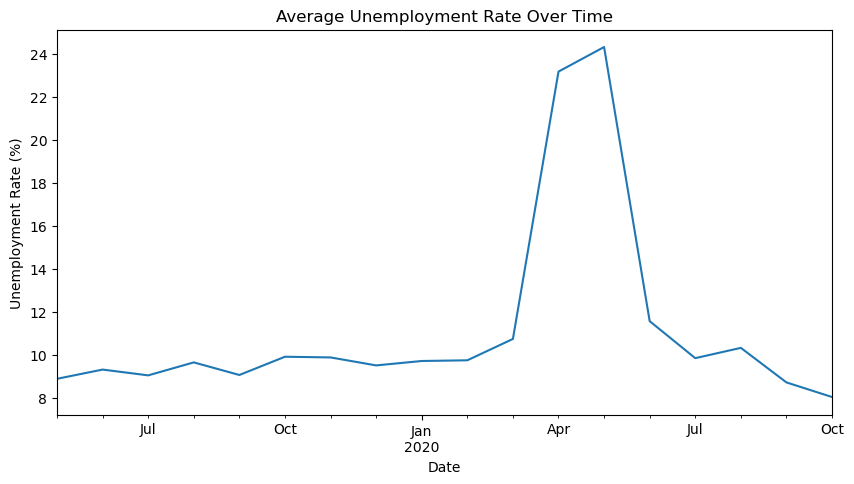

In [7]:
monthly_avg = combined.groupby('Date')['Unemployment_Rate'].mean().sort_index()

plt.figure(figsize=(10,5))
monthly_avg.plot()
plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [9]:
before_covid = combined[combined['Date'] < '2020-03-01']
after_covid = combined[combined['Date'] >= '2020-03-01']

avg_before = before_covid['Unemployment_Rate'].mean()
avg_after = after_covid['Unemployment_Rate'].mean()

print("Average Unemployment Before COVID:", round(avg_before,2), "%")
print("Average Unemployment After COVID:", round(avg_after,2), "%")

Average Unemployment Before COVID: 9.48 %
Average Unemployment After COVID: 15.31 %


In [10]:
state_avg = combined.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

state_avg.head(10)

Region
Tripura             27.483158
Haryana             26.597368
Jharkhand           20.309737
Bihar               19.063684
Himachal Pradesh    17.888947
Delhi               17.000263
Jammu & Kashmir     16.275333
Chandigarh          15.991667
Rajasthan           14.534474
Puducherry          12.361389
Name: Unemployment_Rate, dtype: float64

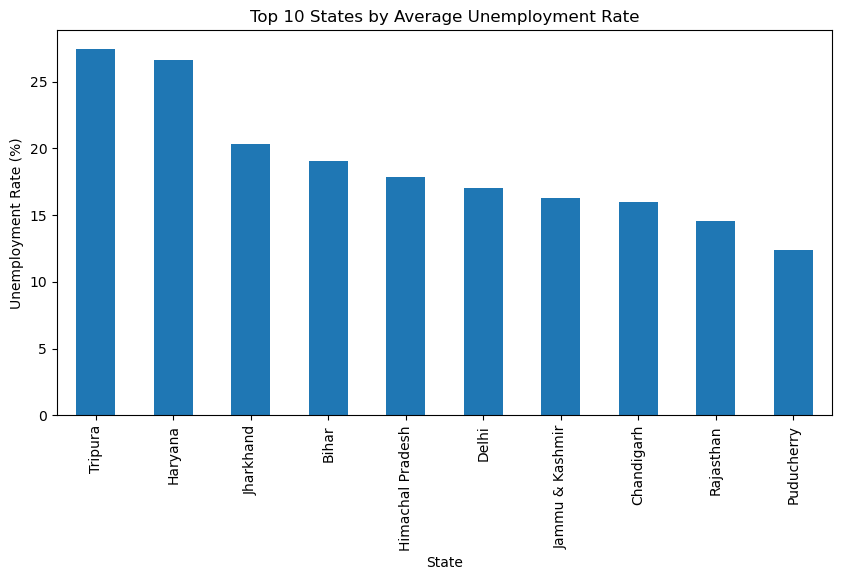

In [11]:
top_states = state_avg.head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [12]:
combined.to_csv('Cleaned_Unemployment_Data.csv', index=False)

In [13]:
combined.isnull().sum()

Region               28
Date                 28
Unemployment_Rate    28
dtype: int64

In [14]:
area_data = df1[['Area', 'Date', 'Unemployment_Rate']].dropna()

area_avg = area_data.groupby('Area')['Unemployment_Rate'].mean()

area_avg

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64

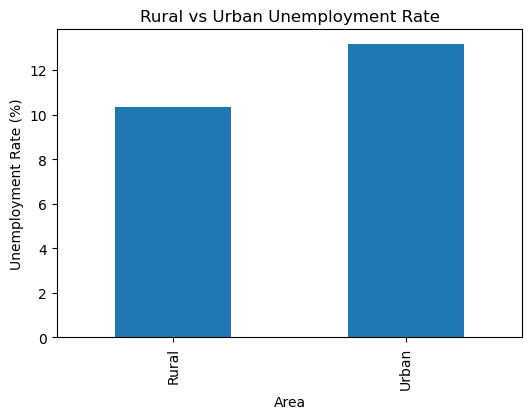

In [15]:
plt.figure(figsize=(6,4))
area_avg.plot(kind='bar')
plt.title('Rural vs Urban Unemployment Rate')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.show()

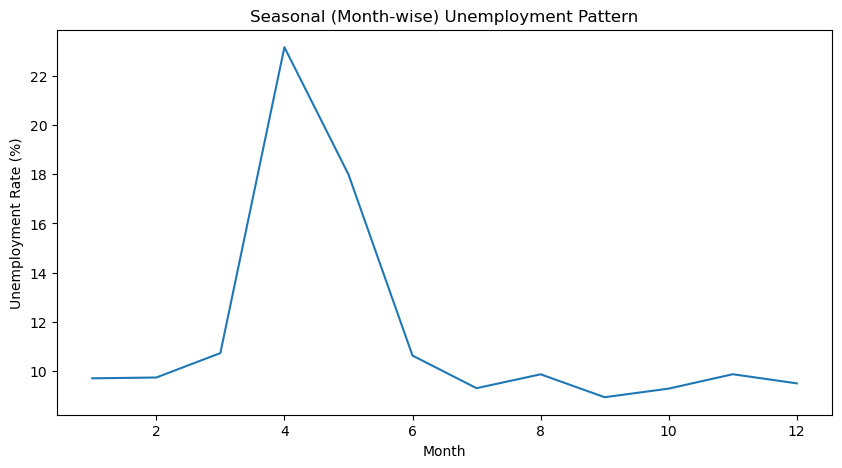

In [16]:
combined['Month'] = combined['Date'].dt.month

month_avg = combined.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))
month_avg.plot()
plt.title('Seasonal (Month-wise) Unemployment Pattern')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [17]:
print("Project Completed: Unemployment Analysis with Python")

Project Completed: Unemployment Analysis with Python
